In [1]:
import optuna
study_name = "ks_sklearn_bdt2"
study = optuna.create_study(directions=["maximize", "minimize"], study_name=study_name, storage="sqlite:///{}.db".format(study_name), load_if_exists=True)

[I 2023-09-09 21:07:48,074] Using an existing study with name 'ks_sklearn_bdt2' instead of creating a new one.


In [2]:
hd = study.trials_dataframe()

In [11]:
hd.rename({'values_0': 'ROC_AUC', 'values_1': 'similarity_test_training'}, inplace=True, axis=1)
hd['params_max_depth'] = hd['params_max_depth'].fillna(4.0)
hd

,number,ROC_AUC,similarity_test_training,datetime_start,datetime_complete,duration,params_eta,params_max_depth,params_n_estimators,system_attrs_nsga2:generation,state
0,0,0.894527,-9.160386,2023-09-08 22:56:35.415000,2023-09-08 22:56:36.413996,0 days 00:00:00.998996,0.08,3.0,200.0,0,COMPLETE
1,1,0.875143,-8.807550,2023-09-08 22:56:36.448048,2023-09-08 22:56:38.083792,0 days 00:00:01.635744,0.01,6.0,225.0,0,COMPLETE
2,2,0.877878,-9.044309,2023-09-08 22:56:38.114348,2023-09-08 22:56:38.964433,0 days 00:00:00.850085,0.03,5.0,100.0,0,COMPLETE
3,3,0.875472,-9.680519,2023-09-08 22:56:39.003222,2023-09-08 22:56:40.092742,0 days 00:00:01.089520,0.02,3.0,275.0,0,COMPLETE
4,4,0.900081,-7.617142,2023-09-08 22:56:40.122110,2023-09-08 22:56:41.829917,0 days 00:00:01.707807,0.07,5.0,300.0,0,COMPLETE
...,...,...,...,...,...,...,...,...,...,...,...
1185,1185,0.899546,-8.765307,2023-09-09 21:02:56.537595,2023-09-09 21:02:57.536446,0 days 00:00:00.998851,0.06,4.0,150.0,23,COMPLETE
1186,1186,0.902286,-8.378724,2023-09-09 21:02:57.570404,2023-09-09 21:02:58.655712,0 days 00:00:01.085308,0.07,4.0,175.0,23,COMPLETE
1187,1187,0.902257,-8.404753,2023-09-09 21:02:58.688979,2023-09-09 21:02:59.899537,0 days 00:00:01.210558,0.05,4.0,225.0,23,COMPLETE
1188,1188,0.893860,-9.071954,2023-09-09 21:02:59.933776,2023-09-09 21:03:00.863989,0 days 00:00:00.930213,0.05,4.0,125.0,23,COMPLETE


In [12]:
import matplotlib.pyplot as plt

Text(0.5, 0, 'BDT ROC AUC')

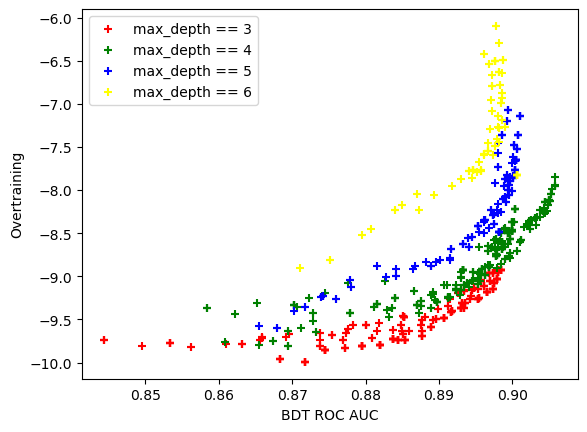

In [13]:
%matplotlib inline 
plt.figure()
#tmp = hd.query("abs(params_eta - 0.03) < 1e3 & params_n_estimators==200")
tmp = hd#.query("abs(params_eta - 0.03) < 1e-3 & params_n_estimators==200")
hd3 = tmp.query("params_max_depth==3")
plt.scatter(hd3['ROC_AUC'], hd3['similarity_test_training'], label="max_depth == 3", c='red', marker='+')
hd4 = tmp.query("params_max_depth==4")
plt.scatter(hd4['ROC_AUC'], hd4['similarity_test_training'], label="max_depth == 4",c='green', marker='+')
hd5 = tmp.query("params_max_depth==5")
plt.scatter(hd5['ROC_AUC'], hd5['similarity_test_training'], label="max_depth == 5",c='blue', marker='+')
hd6 = tmp.query("params_max_depth==6")
plt.scatter(hd6['ROC_AUC'], hd6['similarity_test_training'], label="max_depth == 6",c='yellow', marker='+');
plt.legend()
plt.ylabel("Overtraining")
plt.xlabel("BDT ROC AUC")

In [14]:
tmp

,number,ROC_AUC,similarity_test_training,datetime_start,datetime_complete,duration,params_eta,params_max_depth,params_n_estimators,system_attrs_nsga2:generation,state
0,0,0.894527,-9.160386,2023-09-08 22:56:35.415000,2023-09-08 22:56:36.413996,0 days 00:00:00.998996,0.08,3.0,200.0,0,COMPLETE
1,1,0.875143,-8.807550,2023-09-08 22:56:36.448048,2023-09-08 22:56:38.083792,0 days 00:00:01.635744,0.01,6.0,225.0,0,COMPLETE
2,2,0.877878,-9.044309,2023-09-08 22:56:38.114348,2023-09-08 22:56:38.964433,0 days 00:00:00.850085,0.03,5.0,100.0,0,COMPLETE
3,3,0.875472,-9.680519,2023-09-08 22:56:39.003222,2023-09-08 22:56:40.092742,0 days 00:00:01.089520,0.02,3.0,275.0,0,COMPLETE
4,4,0.900081,-7.617142,2023-09-08 22:56:40.122110,2023-09-08 22:56:41.829917,0 days 00:00:01.707807,0.07,5.0,300.0,0,COMPLETE
...,...,...,...,...,...,...,...,...,...,...,...
1185,1185,0.899546,-8.765307,2023-09-09 21:02:56.537595,2023-09-09 21:02:57.536446,0 days 00:00:00.998851,0.06,4.0,150.0,23,COMPLETE
1186,1186,0.902286,-8.378724,2023-09-09 21:02:57.570404,2023-09-09 21:02:58.655712,0 days 00:00:01.085308,0.07,4.0,175.0,23,COMPLETE
1187,1187,0.902257,-8.404753,2023-09-09 21:02:58.688979,2023-09-09 21:02:59.899537,0 days 00:00:01.210558,0.05,4.0,225.0,23,COMPLETE
1188,1188,0.893860,-9.071954,2023-09-09 21:02:59.933776,2023-09-09 21:03:00.863989,0 days 00:00:00.930213,0.05,4.0,125.0,23,COMPLETE


      number   ROC_AUC  similarity_test_training             datetime_start  \
32        32  0.887530                 -9.287074 2023-09-08 22:57:16.005564   
62        62  0.891497                 -9.235045 2023-09-08 22:57:53.363938   
92        92  0.887530                 -9.287074 2023-09-08 22:58:29.559607   
140      140  0.887530                 -9.287074 2023-09-08 22:59:27.069321   
356      356  0.897839                 -8.735938 2023-09-08 23:03:33.470647   
434      434  0.897839                 -8.735938 2023-09-08 23:05:07.677270   
479      479  0.897839                 -8.735938 2023-09-08 23:06:00.542717   
541      541  0.865542                 -9.801408 2023-09-08 23:07:16.865027   
704      704  0.898962                 -8.619926 2023-09-08 23:10:41.219091   
834      834  0.894098                 -9.125452 2023-09-08 23:13:32.446051   
933      933  0.897839                 -8.735938 2023-09-08 23:15:37.096101   
980      980  0.898962                 -8.619926 202

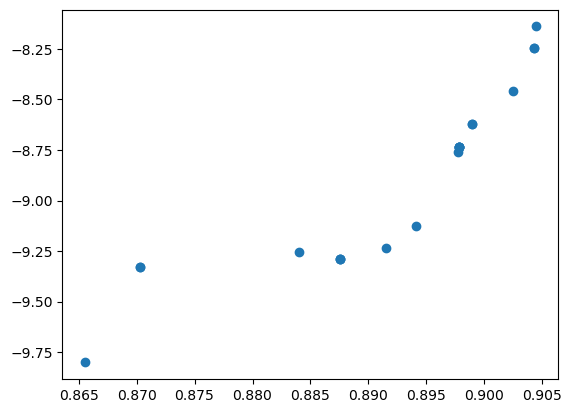

In [16]:
%matplotlib inline
plt.figure()
tmp = hd.query("params_n_estimators==200 & params_max_depth == 4 ")
plt.scatter(tmp['ROC_AUC'], tmp['similarity_test_training'])
# plt.legend()
# plt.ylabel("Overtraining")
# plt.xlabel("BDT ROC AUC")

In [ ]:
tmp['similarity_test_training']

In [ ]:
# %matplotlib widget


# hd3 = hd.query("params_max_depth==3")
# ax = plt.figure().add_subplot(projection='3d')
# ax.scatter(hd3['values_0'], hd3['values_1'], hd3["params_eta"])